<a href="https://colab.research.google.com/github/salmakhale/ML-Data-Analysis/blob/main/Financial_loan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
lorenzozoppelletto_financial_risk_for_loan_approval_path = kagglehub.dataset_download('lorenzozoppelletto/financial-risk-for-loan-approval')

print('Data source import complete.')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/kaggle/input/financial-risk-for-loan-approval/Loan.csv")

In [ ]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [ ]:
df.shape

(20000, 36)

In [ ]:
df.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [ ]:
df.isnull().sum().sort_values().head()

ApplicationDate           0
PaymentHistory            0
LengthOfCreditHistory     0
SavingsAccountBalance     0
CheckingAccountBalance    0
dtype: int64

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.columns

Index(['ApplicationDate', 'Age', 'AnnualIncome', 'CreditScore',
       'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount',
       'LoanDuration', 'MaritalStatus', 'NumberOfDependents',
       'HomeOwnershipStatus', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory',
       'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore'],
      dtype='object')

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
cols = list(df.nunique().sort_values().index[:7])
cols

['BankruptcyHistory',
 'PreviousLoanDefaults',
 'LoanApproved',
 'EmploymentStatus',
 'MaritalStatus',
 'HomeOwnershipStatus',
 'EducationLevel']

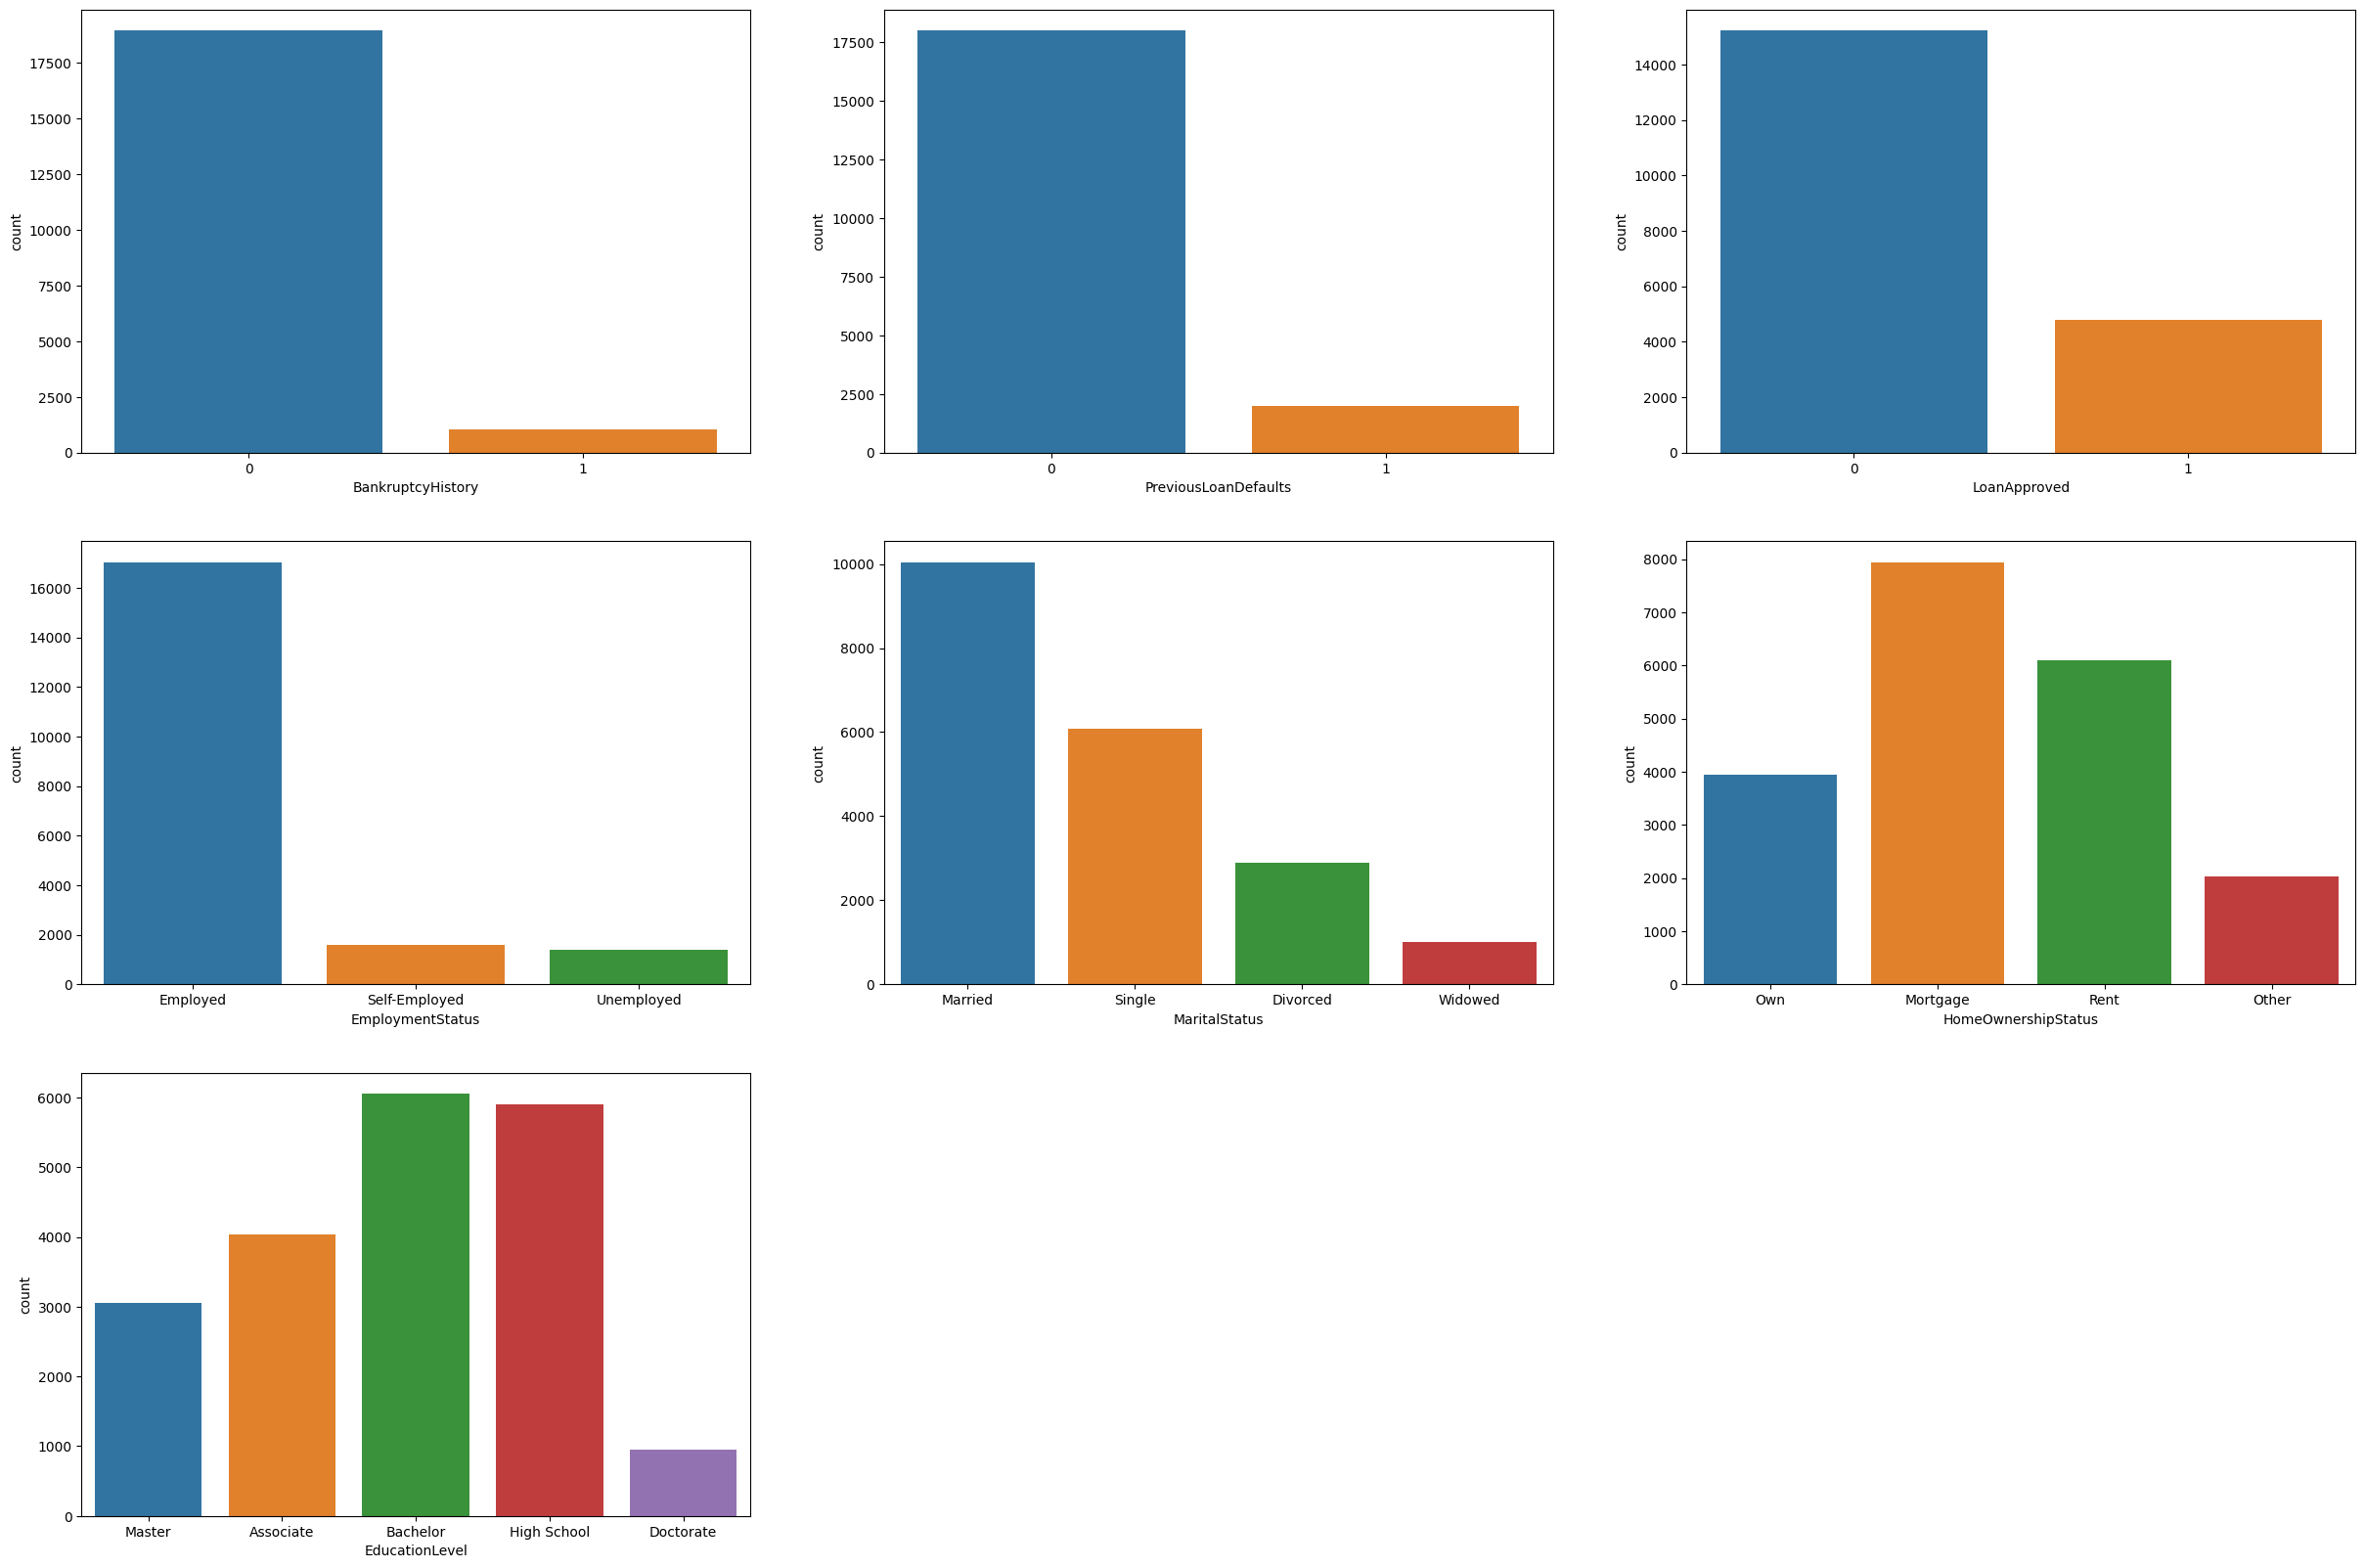

In [ ]:
plt.figure(figsize=(30,20))
for n , col in enumerate(cols) :
    plt.subplot(3,3,n+1)
    sns.countplot(data=df,x=col)


In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='MonthlyIncome',hue='Experience')

<Axes: xlabel='JobTenure', ylabel='LoanApproved'>

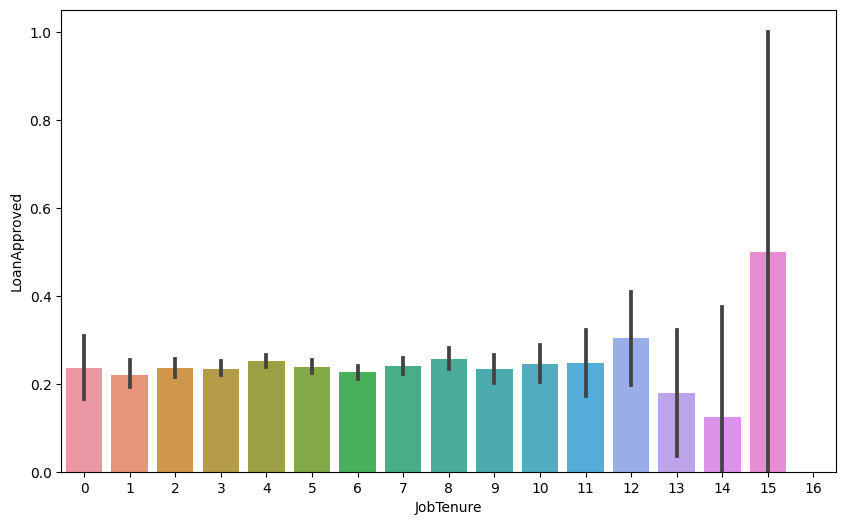

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x ='JobTenure',y='LoanApproved',)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='CreditCardUtilizationRate', ylabel='Count'>

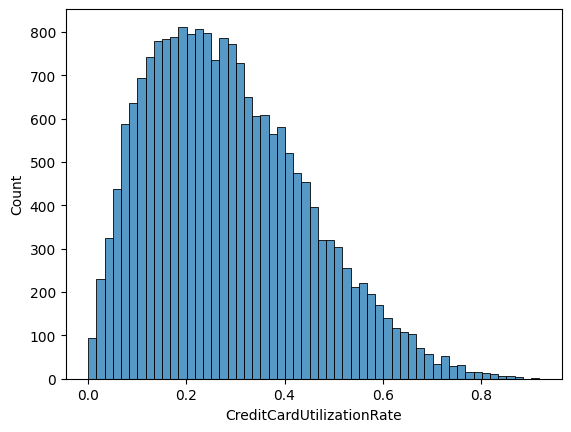

In [ ]:
sns.histplot(data=df,x='CreditCardUtilizationRate')

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='TotalDebtToIncomeRatio', ylabel='Count'>

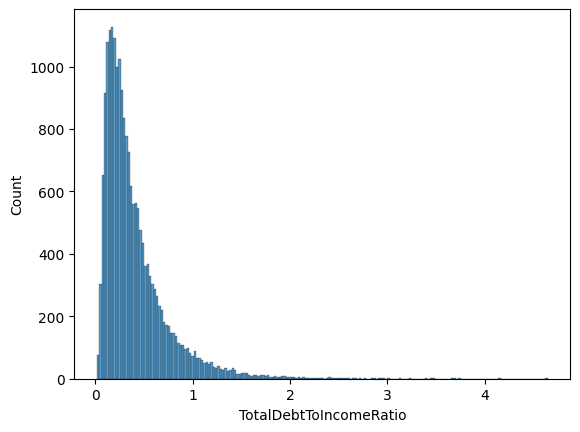

In [ ]:
sns.histplot(data=df,x='TotalDebtToIncomeRatio')

<Axes: xlabel='MaritalStatus', ylabel='RiskScore'>

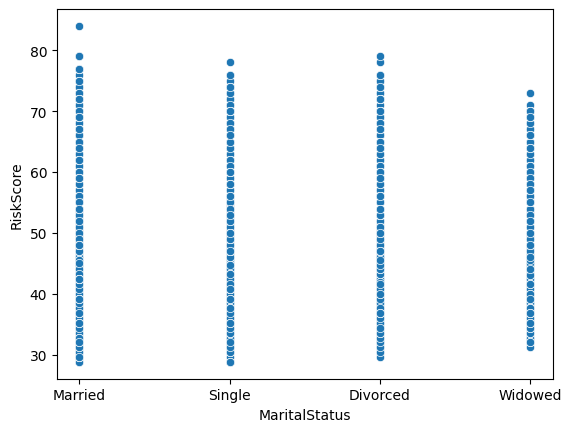

In [ ]:
sns.scatterplot(data=df,x='MaritalStatus',y='RiskScore')

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


(array([-10.,   0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.]),
 [Text(-10.0, 0, '−10'),
  Text(0.0, 0, '0'),
  Text(10.0, 0, '10'),
  Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60'),
  Text(70.0, 0, '70')])

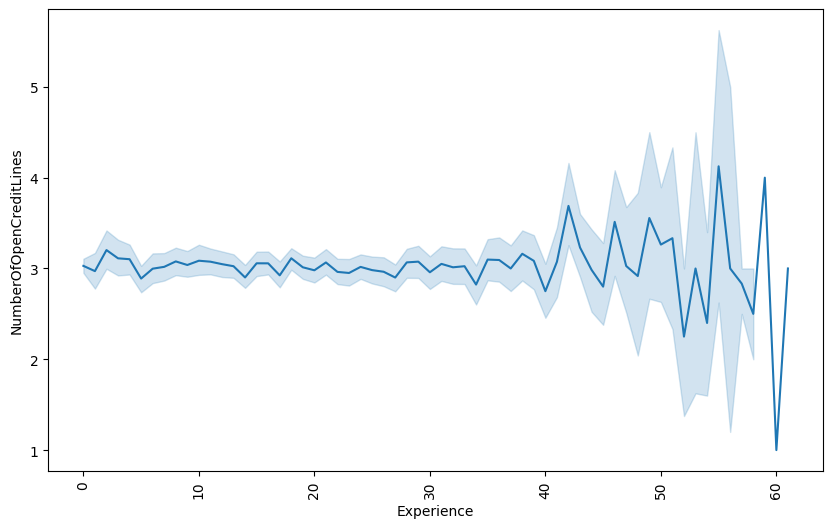

In [ ]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=df, x='Experience', y='NumberOfOpenCreditLines')
plt.xticks(rotation=90)


<Axes: >

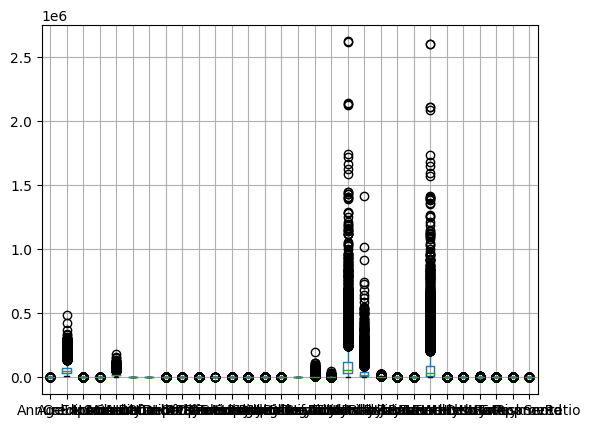

In [ ]:
df.boxplot()

<Axes: xlabel='Age', ylabel='AnnualIncome'>

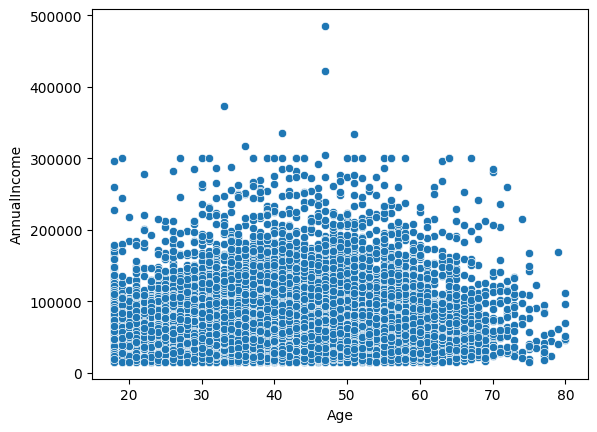

In [ ]:
sns.scatterplot(data=df,x='Age',y='AnnualIncome')

In [ ]:
cols=df.select_dtypes('object')

In [ ]:
cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ApplicationDate      20000 non-null  object
 1   EmploymentStatus     20000 non-null  object
 2   EducationLevel       20000 non-null  object
 3   MaritalStatus        20000 non-null  object
 4   HomeOwnershipStatus  20000 non-null  object
 5   LoanPurpose          20000 non-null  object
dtypes: object(6)
memory usage: 937.6+ KB


In [ ]:
cols.nunique()

ApplicationDate        20000
EmploymentStatus           3
EducationLevel             5
MaritalStatus              4
HomeOwnershipStatus        4
LoanPurpose                5
dtype: int64

In [ ]:
df

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2072-09-29,44,30180,587,Employed,High School,19,24521,36,Married,...,2515.000000,0.826217,1,55327,0.216021,0.195574,905.767712,0.627741,0,55.0
19996,2072-09-30,56,49246,567,Employed,Associate,33,25818,36,Married,...,4103.833333,0.816618,3,64002,0.227318,0.199168,958.395633,0.334418,0,54.0
19997,2072-10-01,44,48958,645,Employed,Bachelor,20,37033,72,Married,...,4079.833333,0.887216,3,103663,0.229533,0.226766,945.427454,0.357227,0,45.0
19998,2072-10-02,60,41025,560,Employed,High School,36,14760,72,Married,...,3418.750000,0.843787,5,10600,0.249760,0.264873,411.168284,0.408678,0,59.0


In [ ]:
print(type('ApplicationDate'))

<class 'str'>


In [ ]:
df['ApplicationDate']=df['ApplicationDate'].astype(str)
df[['year','month','day']]=df['ApplicationDate'].str.split('-',expand=True)
df=df.astype({'year':int ,'month':int,'day':int})


In [ ]:
df

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,year,month,day
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,126928,0.199652,0.227590,419.805992,0.181077,0,49.0,2018,1,1
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,43609,0.207045,0.201077,794.054238,0.389852,0,52.0,2018,1,2
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,5205,0.217627,0.212548,666.406688,0.462157,0,52.0,2018,1,3
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0,2018,1,4
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,227019,0.197184,0.175990,330.179140,0.070210,1,36.0,2018,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2072-09-29,44,30180,587,Employed,High School,19,24521,36,Married,...,55327,0.216021,0.195574,905.767712,0.627741,0,55.0,2072,9,29
19996,2072-09-30,56,49246,567,Employed,Associate,33,25818,36,Married,...,64002,0.227318,0.199168,958.395633,0.334418,0,54.0,2072,9,30
19997,2072-10-01,44,48958,645,Employed,Bachelor,20,37033,72,Married,...,103663,0.229533,0.226766,945.427454,0.357227,0,45.0,2072,10,1
19998,2072-10-02,60,41025,560,Employed,High School,36,14760,72,Married,...,10600,0.249760,0.264873,411.168284,0.408678,0,59.0,2072,10,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
for a in ['ApplicationDate' , 'EmploymentStatus' ,'EducationLevel' ,'MaritalStatus','HomeOwnershipStatus','LoanPurpose']:
    lb = LabelEncoder()
    df[a] = lb.fit_transform(df[a])


In [ ]:
df['EmploymentStatus'].unique()

array([0, 1, 2])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  int64  
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  int64  
 5   EducationLevel              20000 non-null  int64  
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  int64  
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  int64  
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [ ]:
df = df.drop(['ApplicationDate','year'],axis =1)

In [ ]:
df.shape

(20000, 37)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  int64  
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  int64  
 4   EducationLevel              20000 non-null  int64  
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               20000 non-null  int64  
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  int64  
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

# #Regression******

In [ ]:
X=df.drop(['RiskScore'],axis =1)

In [ ]:
X.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,month,day
0,45,39948,617,0,4,22,13152,48,1,2,...,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,1,1
1,38,39709,628,0,0,15,26045,48,2,1,...,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,1,2
2,47,40724,570,0,1,26,17627,36,1,2,...,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,1,3
3,58,69084,545,0,3,34,37898,96,2,1,...,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,1,4
4,37,103264,594,0,0,17,9184,36,1,1,...,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,1,5


In [ ]:
y= df['RiskScore']

In [ ]:
y.head()

0    49.0
1    52.0
2    52.0
3    54.0
4    36.0
Name: RiskScore, dtype: float64

In [ ]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler

In [ ]:
scaler = RobustScaler()
X_scaler = scaler.fit_transform(X)

In [ ]:
X_scaler

array([[ 0.3125    , -0.20176999,  0.56521739, ...,  0.        ,
        -1.2       , -1.        ],
       [-0.125     , -0.20736561,  0.72463768, ...,  0.        ,
        -1.2       , -0.93333333],
       [ 0.4375    , -0.1836018 , -0.11594203, ...,  0.        ,
        -1.2       , -0.86666667],
       ...,
       [ 0.25      ,  0.00917775,  0.97101449, ...,  0.        ,
         0.6       , -1.        ],
       [ 1.25      , -0.1765546 , -0.26086957, ...,  0.        ,
         0.6       , -0.93333333],
       [-1.25      ,  0.10912624, -0.05797101, ...,  0.        ,
         0.6       , -0.86666667]])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaler,y,test_size= 0.2, random_state=100)

In [ ]:
print("X_train = ",X_train.shape ," y_train = ", y_train.shape)
print("X_test  = ",X_test.shape ," y_test  = ", y_test.shape)

X_train =  (16000, 36)  y_train =  (16000,)
X_test  =  (4000, 36)  y_test  =  (4000,)


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
LR_model = LinearRegression()
LR_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
LR_model.score(X_train,y_train)

0.9364980321948536

In [ ]:
LR_model.score(X_test,y_test)

0.9400373127483982

In [ ]:
y_pred = LR_model.predict(X_test)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
DT = DecisionTreeRegressor(criterion='squared_error',max_depth=None)

In [ ]:
DT.fit(X_train,y_train)

DecisionTreeRegressor()

In [ ]:
DT.score(X_train,y_train)

1.0

In [ ]:
DT.score(X_test,y_test)

0.9667649696616919

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
RF = RandomForestRegressor(n_estimators=50 ,criterion='squared_error',max_depth=None)

In [ ]:
RF.fit(X_train,y_train)

RandomForestRegressor(n_estimators=50)

In [ ]:
RF.score(X_train,y_train)

0.9977494919842413

In [ ]:
DT.score(X_test,y_test)

0.9667649696616919

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
knn = KNeighborsRegressor(n_neighbors=5,metric='euclidean',p=1)

In [ ]:
knn.fit(X_train,y_train)

KNeighborsRegressor(metric='euclidean', p=1)

In [ ]:
knn.score(X_train,y_train)

0.7518967963447587

In [ ]:
knn.score(X_test,y_test)

0.613670968148528

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
model = keras.models.Sequential()
model.add(keras.layers.Dense(100, activation="relu", input_shape = X_train.shape[1:]))  # input_dim = 8
model.add(keras.layers.Dense(25, activation="relu"))
model.add(keras.layers.Dense(25, activation="relu"))
model.add(keras.layers.Dense(8, activation="relu"))
model.add(keras.layers.Dense(1, activation="relu"))



/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss="mean_squared_error", optimizer="sgd", metrics=["mae"])

history = model.fit(X_train, y_train, epochs=30, batch_size=128, validation_split=0.2)


Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3851401.0000 - mae: 391.6275 - val_loss: 2646.6619 - val_mae: 50.8560
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2634.1140 - mae: 50.7277 - val_loss: 2646.6619 - val_mae: 50.8560
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2632.6758 - mae: 50.7114 - val_loss: 2646.6619 - val_mae: 50.8560
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2634.7417 - mae: 50.7413 - val_loss: 2646.6619 - val_mae: 50.8560
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2648.6604 - mae: 50.8777 - val_loss: 2646.6619 - val_mae: 50.8560
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2639.1541 - mae: 50.7848 - val_loss: 2646.6619 - val_mae: 50.8560
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2637.0327 - mae: 50.7584 - val_loss: 2646.6619 - val_mae: 50.8560
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2649.4844 - mae: 50.8819 - val_loss: 2646.6619 - val_m

In [ ]:
history.history

{'loss': [1053989.875,
  2634.810302734375,
  2634.810302734375,
  2634.810302734375,
  2634.810546875,
  2634.810302734375,
  2634.810546875,
  2634.811279296875,
  2634.811279296875,
  2634.811279296875,
  2634.81103515625,
  2634.81103515625,
  2634.81103515625,
  2634.81103515625,
  2634.811279296875,
  2634.8115234375,
  2634.81103515625,
  2634.810546875,
  2634.810546875,
  2634.810546875,
  2634.810546875,
  2634.810546875,
  2634.811279296875,
  2634.81103515625,
  2634.81103515625,
  2634.810302734375,
  2634.810546875,
  2634.811279296875,
  2634.810546875,
  2634.810302734375],
 'mae': [143.87026977539062,
  50.738224029541016,
  50.73824691772461,
  50.73824691772461,
  50.73823547363281,
  50.73823547363281,
  50.738243103027344,
  50.73823165893555,
  50.73824691772461,
  50.73823547363281,
  50.73823165893555,
  50.73822784423828,
  50.73823165893555,
  50.73823547363281,
  50.73822784423828,
  50.73823165893555,
  50.73822784423828,
  50.738243103027344,
  50.738231658

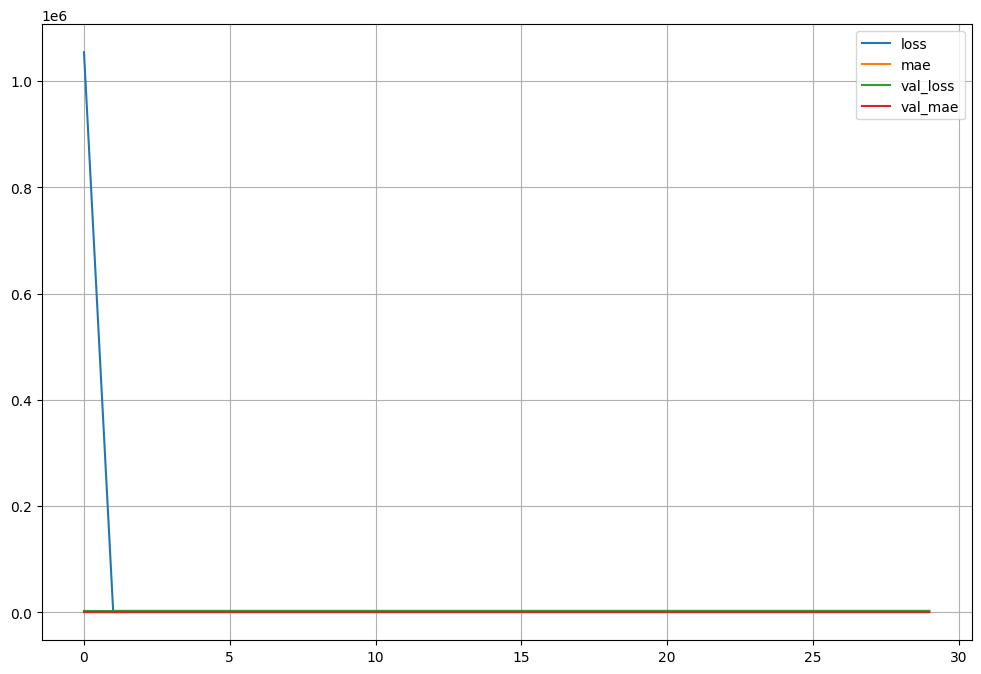

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2633.9705 - mae: 50.7111
Loss                   :  2640.09716796875
Mean Absolute Error     :  50.7867546081543


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(12, 8))
plt.grid(True)
plt.show()

model_evaluate = model.evaluate(X_test, y_test)
print("Loss                   : ",model_evaluate[0])
print("Mean Absolute Error     : ",model_evaluate[1])


# Classification

In [ ]:
X=df.drop(['LoanApproved'],axis =1)

In [ ]:
X.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore,month,day
0,45,39948,617,0,4,22,13152,48,1,2,...,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,49.0,1,1
1,38,39709,628,0,0,15,26045,48,2,1,...,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,52.0,1,2
2,47,40724,570,0,1,26,17627,36,1,2,...,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,52.0,1,3
3,58,69084,545,0,3,34,37898,96,2,1,...,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,54.0,1,4
4,37,103264,594,0,0,17,9184,36,1,1,...,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,36.0,1,5


In [ ]:
y= df['LoanApproved']

In [ ]:
y.head()

0    0
1    0
2    0
3    0
4    1
Name: LoanApproved, dtype: int64

In [ ]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler

In [ ]:
scaler = RobustScaler()
X_scaler = scaler.fit_transform(X)

In [ ]:
X_scaler

array([[ 0.3125    , -0.20176999,  0.56521739, ..., -0.3       ,
        -1.2       , -1.        ],
       [-0.125     , -0.20736561,  0.72463768, ...,  0.        ,
        -1.2       , -0.93333333],
       [ 0.4375    , -0.1836018 , -0.11594203, ...,  0.        ,
        -1.2       , -0.86666667],
       ...,
       [ 0.25      ,  0.00917775,  0.97101449, ..., -0.7       ,
         0.6       , -1.        ],
       [ 1.25      , -0.1765546 , -0.26086957, ...,  0.7       ,
         0.6       , -0.93333333],
       [-1.25      ,  0.10912624, -0.05797101, ...,  0.7       ,
         0.6       , -0.86666667]])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
print("X_train = ",X_train.shape ," y_train = ", y_train.shape)
print("X_test  = ",X_test.shape ," y_test  = ", y_test.shape)

X_train =  (16000, 36)  y_train =  (16000,)
X_test  =  (4000, 36)  y_test  =  (4000,)


# Neural Network

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
y_train

1259     39.2
5991     60.0
8998     35.2
18072    42.4
12949    40.8
         ... 
16304    51.2
79       64.0
12119    50.0
14147    39.2
5640     51.0
Name: RiskScore, Length: 16000, dtype: float64

In [ ]:
model = keras.Sequential()
model.add(keras.layers.Dense(32,  activation="relu", input_shape = X_train.shape[1:]))
model.add(keras.layers.Dense(16, activation="relu"))
model.add(keras.layers.Dense(8, activation="relu"))
model.add(keras.layers.Dense(1, activation="linear"))


In [ ]:
model.compile(loss="mse", optimizer="adam", metrics=["mae"])

history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.2316 - mae: 1.1887 - val_loss: 2.2732 - val_mae: 1.1859
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.0419 - mae: 1.1316 - val_loss: 2.3135 - val_mae: 1.2126
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.9944 - mae: 1.1245 - val_loss: 2.1894 - val_mae: 1.1705
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9409 - mae: 1.1051 - val_loss: 2.2941 - val_mae: 1.2029
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.9204 - mae: 1.0959 - val_loss: 2.1842 - val_mae: 1.1615
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.8345 - mae: 1.0791 - val_loss: 1.9717 - val_mae: 1.1022
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8380 - mae: 1.0714 - val_loss: 1.9466 - val_mae: 1.0998
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.7026 - mae: 1.0342 - val_loss: 1.9422 - val_mae: 1.1059
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

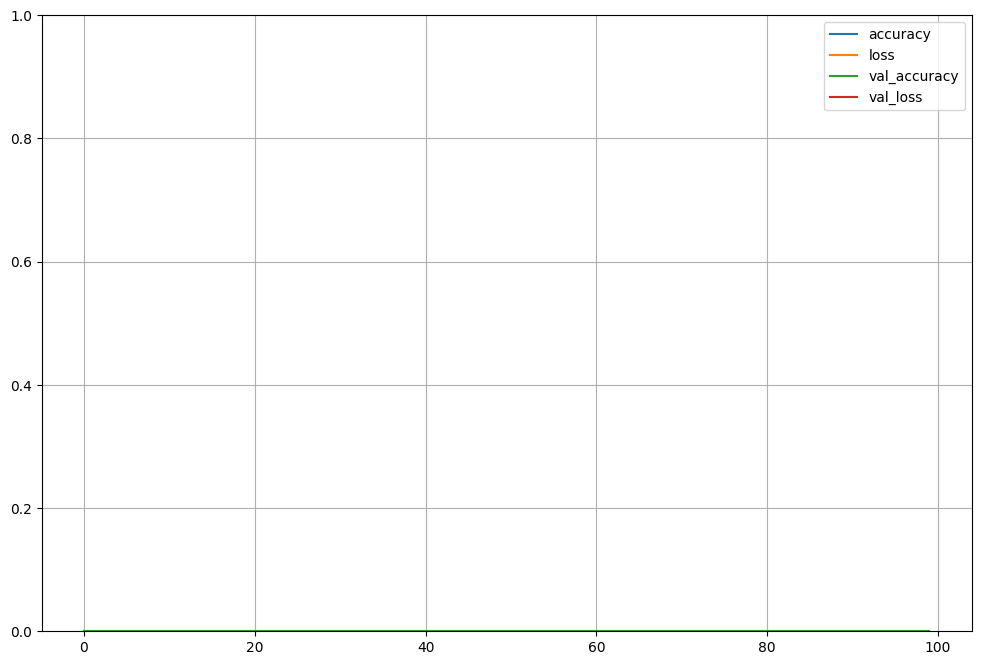

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: -792.1213
Loss     :  -793.5369262695312
accuracy :  0.0


In [ ]:
pd.DataFrame(history.history).plot(figsize=(12, 8))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

model_evaluate = model.evaluate(X_test, y_test)
print("Loss     : ",model_evaluate[0])
print("accuracy : ",model_evaluate[1])


In [ ]:
model.predict(X_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[2.3277826],
       [3.5065813],
       [3.9275706],
       ...,
       [1.7978424],
       [2.6708348],
       [4.0925026]], dtype=float32)

In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype("int32").tolist()

y_pred

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


[[1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1],
 [1]

In [ ]:
class_names = ["0", "1"]

from sklearn.metrics import classification_report, confusion_matrix
print("Classification report : \n",classification_report(y_test, y_pred, target_names = class_names))

import seaborn as sns
def draw_confusion_matrix(true, preds, normalize=None):
    conf_matx = confusion_matrix(true, preds, normalize = normalize)
    conf_matx = np.round(conf_matx, 2)
    print(conf_matx)

    sns.heatmap(conf_matx, annot=True, annot_kws={"size": 12},fmt="g", cbar=False, cmap="yellows")
    plt.show()

print("Confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred)

print("Normalized confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred, "true")


ValueError: Classification metrics can't handle a mix of continuous and binary targets